In [2]:
import matplotlib.pyplot as plt
import vector as vec
import numpy as np
import pandas as pd

In [3]:
def v(df, name):
    return vec.array({"px": df[f"{name}_px"], "py": df[f"{name}_py"],
                         "pz": df[f"{name}_pz"], "E":  df[f"{name}_E"]})


def calculo_rangos(lim_inf, lim_sup, data):

    if type(data) == list:

        total_events = sum(len(data_i) for data_i in data)

        debajo = sum(np.sum(data_i < lim_inf) for data_i in data)

        dentro = sum(
            np.sum((data_i >= lim_inf) & (data_i <= lim_sup))
            for data_i in data
        )

        encima = sum(np.sum(data_i > lim_sup) for data_i in data)

        p_debajo = 100 * debajo / total_events
        p_dentro = 100 * dentro / total_events
        p_encima = 100 * encima / total_events

        return lim_inf, lim_sup, p_debajo, p_dentro, p_encima

    else:

        return print("Error: data debe ser una lista de arrays de datos.")

In [4]:
signal = pd.read_csv('/home/usuario/Madgraph/diHiggsAnalysis/Build/LQ_bbtautau/diHiggs.csv')
standard = pd.read_csv('/home/usuario/Madgraph/diHiggsAnalysis/Build/SM_bbtautau/SM_diHiggs.csv')
bg_hlep = pd.read_csv('/home/usuario/Madgraph/diHiggsAnalysis/Build/BG_ttbar_hlep/ttbarh_hlep.csv')

In [5]:
# Defino los cuatrivectores de los jets y los taus

# Signal
b, bbar    = v(signal,"b"), v(signal,"bbar")
taum, taup = v(signal,"taum"), v(signal,"taup")

h_lep = taum + taup
h_had = b + bbar

# Standard Model
SM_b, SM_bbar    = v(standard,"b"), v(standard,"bbar")
SM_taum, SM_taup = v(standard,"taum"), v(standard,"taup")

h_lep_SM = SM_taum + SM_taup
h_had_SM = SM_b + SM_bbar

# BG: gg > t t~ h, (t -> W + b, W -> lep(e, u)), (h -> tau tau)

BG_b, BG_bbar    = v(bg_hlep,"b"), v(bg_hlep,"bbar")
BG_taum, BG_taup = v(bg_hlep,"taum"), v(bg_hlep,"taup")
BG_lepm, BG_lepp = v(bg_hlep,"lepm"), v(bg_hlep,"lepp")
BG_nu, BG_nubar  = v(bg_hlep,"nu"), v(bg_hlep,"nubar")
BG_t, BG_tbar    = v(bg_hlep,"t"), v(bg_hlep,"tbar")
BG_h_tt       = v(bg_hlep,"h_tt")

BG_Wp = BG_lepp + BG_nu
BG_Wm = BG_lepm + BG_nubar


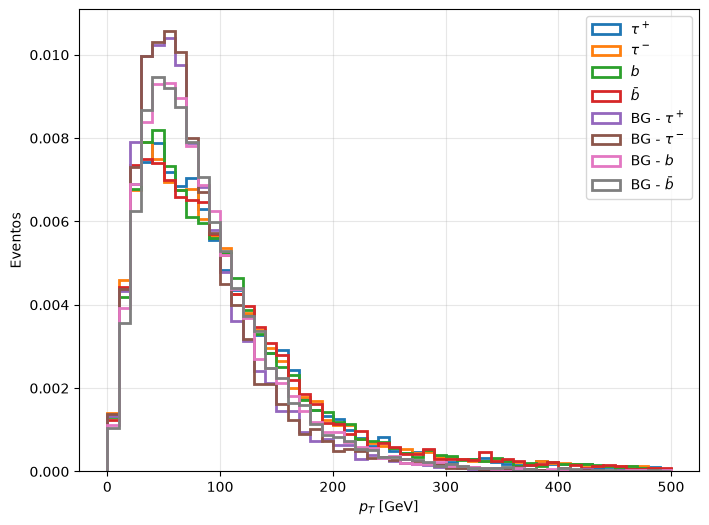

In [6]:
plt.figure(figsize=(8,6))

plt.hist(taum.pt,bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$\tau^+$")
plt.hist(taup.pt,bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$\tau^-$")
plt.hist(b.pt,bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$b$")
plt.hist(bbar.pt,bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$\bar{b}$")

plt.hist(BG_taum.pt,bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"BG - $\tau^+$")
plt.hist(BG_taup.pt,bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"BG - $\tau^-$")
plt.hist(BG_b.pt,bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"BG - $b$")
plt.hist(BG_bbar.pt,bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"BG - $\bar{b}$")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Eventos")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("pt_distribution.png", dpi=300)

plt.show()

In [7]:
# SIGNAL:
MLQ_tautau = (taum + taup).mass
MLQ_bb = (b + bbar).mass
MLQ_hh = (taup + taum + bbar + b).mass

# BG:

MBG_h_tt = (BG_taum + BG_taup).mass
MBG_tautau = (BG_taum + BG_taup).mass
MBG_t = (BG_b + BG_Wp).mass
MBG_tbar = (BG_bbar + BG_Wm).mass
MBG_ttbarh = (BG_b + BG_Wp + BG_bbar + BG_Wm + BG_taum + BG_taup).mass

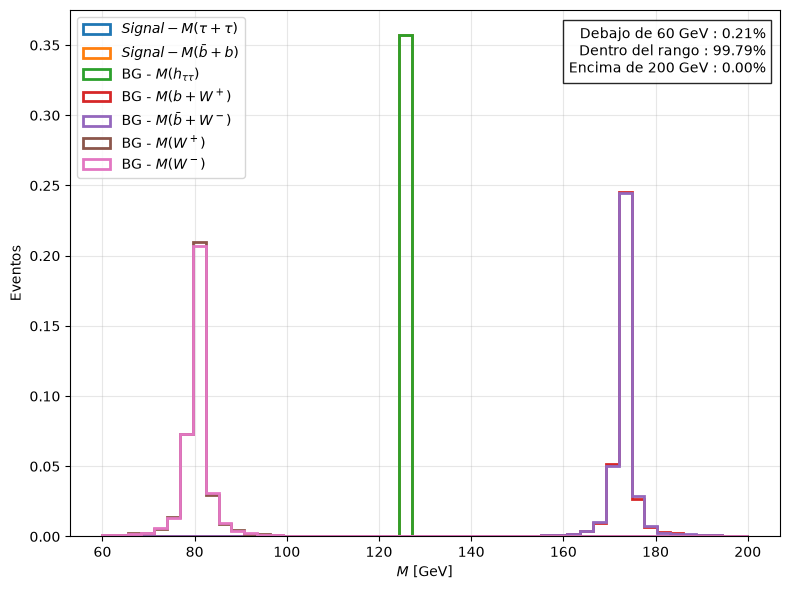

In [8]:
data = [BG_Wm.mass, BG_Wp.mass, MBG_t, MBG_tbar, MBG_h_tt]

lim_inf, lim_sup, p_debajo, p_dentro, p_encima = calculo_rangos(60,200, data)


plt.figure(figsize=(8,6))

texto = (
    f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"
    f"Dentro del rango : {p_dentro:.2f}%\n"
    f"Encima de {lim_sup} GeV : {p_encima:.2f}%"
)

plt.text(
    0.98, 0.97,
    texto,
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

plt.hist(MLQ_tautau, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Signal - M(\tau + \tau)$")
plt.hist(MLQ_bb, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Signal - M(\bar{b} + b)$")
plt.hist(MBG_h_tt, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"BG - $M(h_{\tau\tau})$")
plt.hist(MBG_t, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"BG - $M(b + W^+)$")
plt.hist(MBG_tbar, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"BG - $M(\bar{b} + W^-)$")
plt.hist(BG_Wp.mass, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"BG - $M(W^+)$")
plt.hist(BG_Wm.mass, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"BG - $M(W^-)$")
plt.xlabel(r"$M$ [GeV]")
plt.ylabel("Eventos")
plt.legend()
plt.grid(alpha=0.3)


plt.tight_layout()

plt.savefig("MassControl.png", dpi=300)
plt.show()

In [9]:
# Diferencias de masas invariantes entre señal y fondo, construidas analogamente

BG_M_hh = (BG_taum + BG_taup + BG_bbar + BG_b).mass
SM_M_hh = (SM_taum + SM_taup + SM_bbar + SM_b).mass


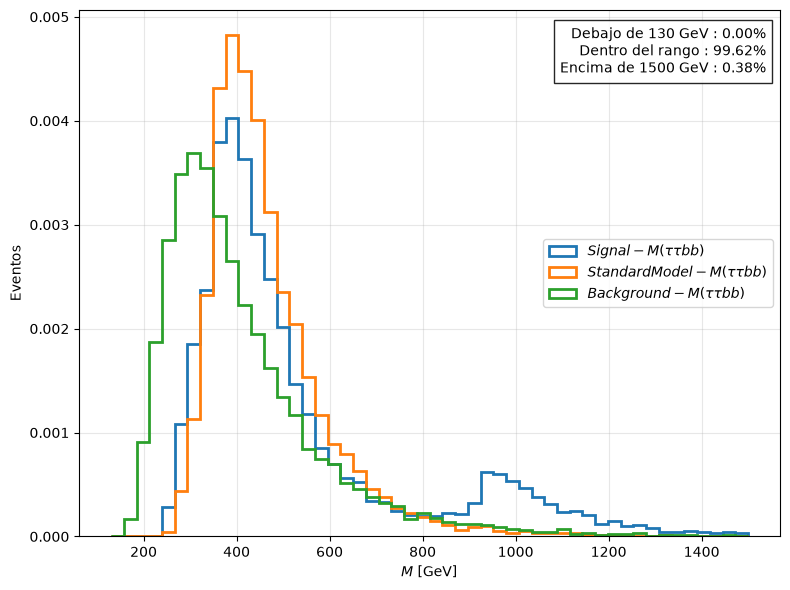

In [10]:
data = [BG_M_hh, MLQ_hh]

lim_inf, lim_sup, p_debajo, p_dentro, p_encima = calculo_rangos(130,1500, data)

plt.figure(figsize=(8,6))

texto = (
    f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"
    f"Dentro del rango : {p_dentro:.2f}%\n"
    f"Encima de {lim_sup} GeV : {p_encima:.2f}%"
)

plt.text(
    0.98, 0.97,
    texto,
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

# --- Subplot izquierdo: señal ---
plt.hist(MLQ_hh, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Signal - M(\tau \tau b b)$")
plt.hist(SM_M_hh, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Standard Model - M(\tau \tau b b)$")
plt.hist(BG_M_hh, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Background - M(\tau \tau b b)$")
plt.xlabel(r"$M$ [GeV]")
plt.ylabel("Eventos")
plt.legend()
plt.grid(alpha=0.3)


plt.tight_layout()
plt.savefig("InvariantMass_distribution.png", dpi=300)
plt.show()

In [11]:
# Calculo de DeltaR's

DeltaR_tautau = taum.deltaR(taup)
DeltaR_bb = b.deltaR(bbar)

DeltaR_SM_tautau = SM_taum.deltaR(SM_taup)
DeltaR_SM_bb = SM_b.deltaR(SM_bbar)

DeltaR_BG_tautau = BG_taum.deltaR(BG_taup)
DeltaR_BG_bb = BG_b.deltaR(BG_bbar)

In [12]:
list_taus_u600 = []
list_bs_u600 = []

list_taus_o800 = []
list_bs_o800 = []

for vec_tau, vec_antitau, vec_b, vec_antib in zip(taum, taup, b, bbar):

    M = (vec_tau + vec_antitau + vec_b + vec_antib).mass

    if 200 < M < 600:

        DeltaR_tautau_200_600 = vec_tau.deltaR(vec_antitau)
        DeltaR_bb_200_600 = vec_b.deltaR(vec_antib)

        list_taus_u600.append(DeltaR_tautau_200_600)
        list_bs_u600.append(DeltaR_bb_200_600)

    elif 800 < M < 1200:

        DeltaR_tautau_800_1200 = vec_tau.deltaR(vec_antitau)
        DeltaR_bb_800_1200 = vec_b.deltaR(vec_antib)

        list_taus_o800.append(DeltaR_tautau_800_1200)
        list_bs_o800.append(DeltaR_bb_800_1200)

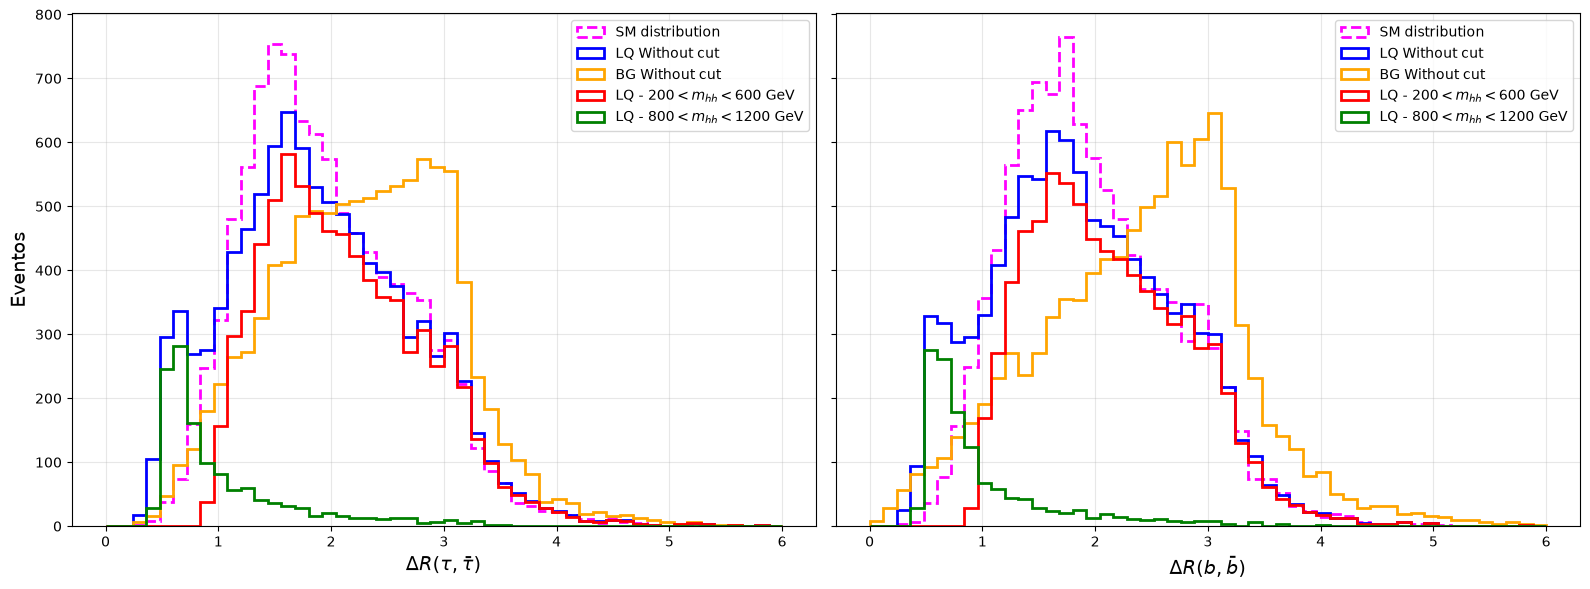

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# ==========================================================
# Primer gráfico
# ==========================================================

ax1.hist(DeltaR_SM_tautau,bins=50,range=(0,6),histtype="step",color="magenta",linestyle="--",linewidth=2,label="SM distribution")

ax1.hist(DeltaR_tautau,bins=50,range=(0,6),histtype="step",color="blue",linewidth=2,label="LQ Without cut")

ax1.hist(DeltaR_BG_tautau,bins=50,range=(0,6),histtype="step",color="orange",linewidth=2,label="BG Without cut")

ax1.hist(list_taus_u600,bins=50,range=(0,6),histtype="step",color="red",linewidth=2,label=r"LQ - $200<m_{hh}<600$ GeV")

ax1.hist(list_taus_o800,bins=50,range=(0,6),histtype="step",color="green",linewidth=2,label=r"LQ - $800<m_{hh}<1200$ GeV")

ax1.set_xlabel(r"$\Delta R(\tau,\bar \tau)$", fontsize=14)
ax1.set_ylabel("Eventos", fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)

# ==========================================================
# Segundo gráfico
# ==========================================================

ax2.hist(DeltaR_SM_bb,bins=50,range=(0,6),histtype="step",color="magenta",linestyle="--",linewidth=2,label="SM distribution")

ax2.hist(DeltaR_bb,bins=50,range=(0,6),histtype="step",color="blue",linewidth=2,label="LQ Without cut")

ax2.hist(DeltaR_BG_bb,bins=50,range=(0,6),histtype="step",color="orange",linewidth=2,label="BG Without cut")

ax2.hist(list_bs_u600,bins=50,range=(0,6),histtype="step",color="red",linewidth=2,label=r"LQ - $200<m_{hh}<600$ GeV")

ax2.hist(list_bs_o800,bins=50,range=(0,6),histtype="step",color="green",linewidth=2,label=r"LQ - $800<m_{hh}<1200$ GeV")

ax2.set_xlabel(r"$\Delta R(b,\bar b)$", fontsize=14)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)

# ==========================================================
# Ajustes finales
# ==========================================================

plt.tight_layout()

plt.savefig("DeltaR_distribution.png", dpi=300)

plt.show()

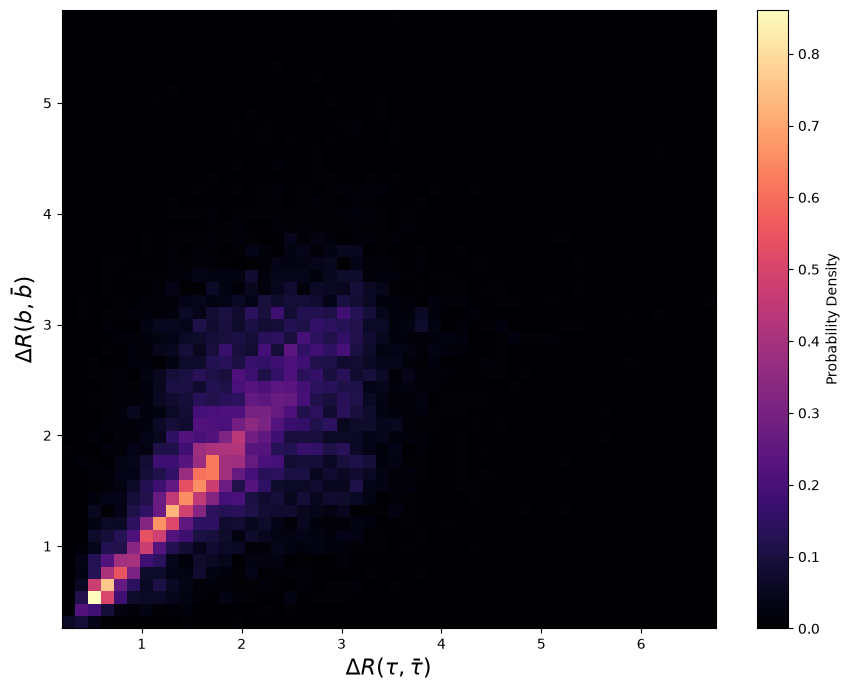

In [14]:
# Grafico 2D de DeltaR(tau tau) vs DeltaR(b b)

plt.figure(figsize=(9,7))

plt.hist2d(DeltaR_tautau, DeltaR_bb, bins=50, cmap="magma", density=True)
# plt.hist2d(DeltaR_SM_tautau, DeltaR_SM_bb, bins=50, cmap="viridis", density=True)

plt.colorbar(label="Probability Density")
plt.xlabel(r"$\Delta R(\tau,\bar \tau)$", fontsize=16)
plt.ylabel(r"$\Delta R(b,\bar b)$", fontsize=16)

plt.tight_layout()
plt.savefig("2D-DeltaR_distribution.png", dpi=300)
plt.show()



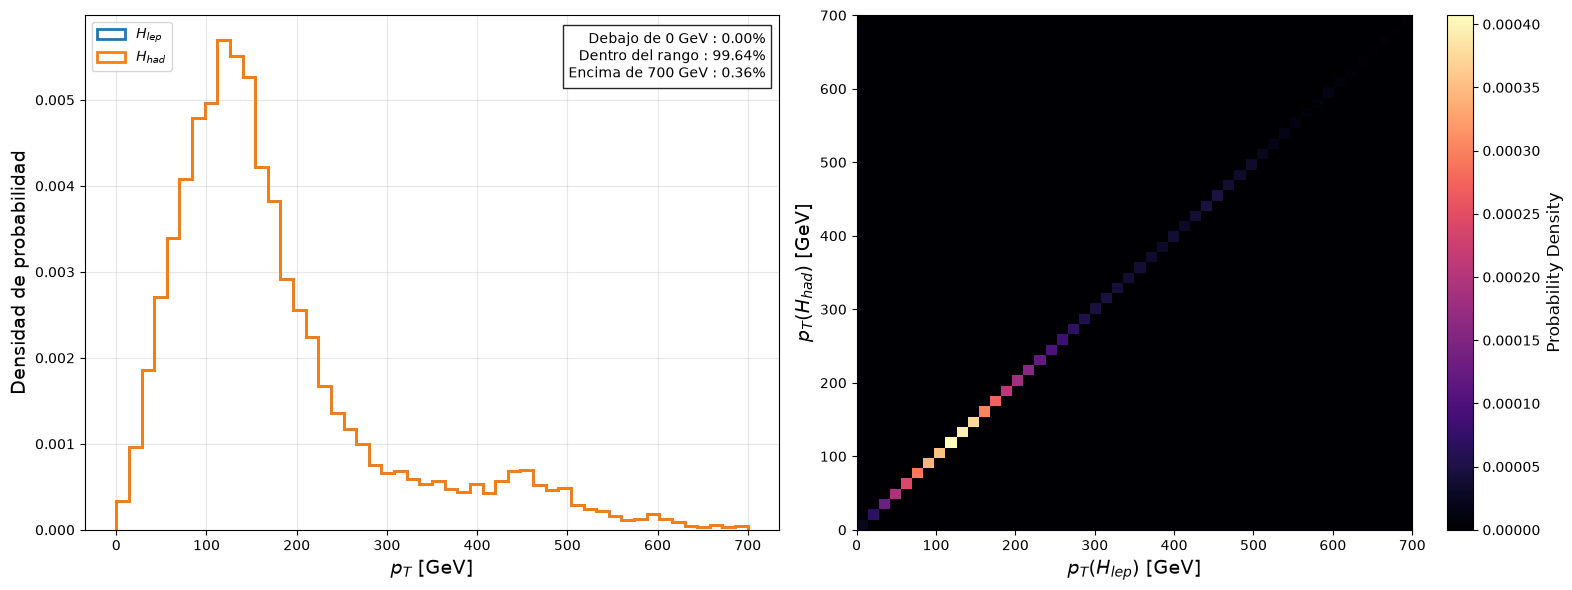

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# ==========================================================
# Primer gráfico
# ==========================================================

data = [h_lep.pt, h_had.pt, h_lep_SM.pt, h_had_SM.pt]

inf = 0
sup = 700

lim_inf, lim_sup, p_debajo, p_dentro, p_encima = calculo_rangos(inf, sup, data)

texto = (
    f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"
    f"Dentro del rango : {p_dentro:.2f}%\n"
    f"Encima de {lim_sup} GeV : {p_encima:.2f}%"
)

ax1.text(
    0.98, 0.97,
    texto,
    transform=ax1.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

ax1.hist(h_lep.pt, bins=50, density=True, range=(inf, sup),
         histtype="step", linewidth=2, label=r"$H_{lep}$")

ax1.hist(h_had.pt, bins=50, density=True, range=(inf, sup),
         histtype="step", linewidth=2, label=r"$H_{had}$")

ax1.hist(h_lep_SM.pt, bins=50, density=True, range=(inf, sup),
         histtype="step", linewidth=2, label=r"SM - $H_{lep}$")

ax1.hist(h_had_SM.pt, bins=50, density=True, range=(inf, sup),
         histtype="step", linewidth=2, label=r"SM - $H_{had}$")

ax1.set_xlabel(r"$p_T$ [GeV]", fontsize=14)
ax1.set_ylabel("Densidad de probabilidad", fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)


# ==========================================================
# Segundo gráfico
# ==========================================================

hist = ax2.hist2d(
    h_lep.pt,
    h_had.pt,
    bins=50,
    range=[[inf, sup], [inf, sup]],
    cmap="magma",
    density=True
)

cbar = fig.colorbar(hist[3], ax=ax2)
cbar.set_label("Probability Density", fontsize=12)

ax2.set_xlabel(r"$p_T(H_{lep})$ [GeV]", fontsize=14)
ax2.set_ylabel(r"$p_T(H_{had})$ [GeV]", fontsize=14)


# ==========================================================
# Ajustes finales
# ==========================================================

plt.tight_layout()

plt.savefig("2D-HpT-Distribution.png", dpi=300)

plt.show()